# Project: Transformer 노드를 GPT-1으로 변경하여 구현하기 (v3)

베이스 코드: 노드 5 Transformer 챗봇 (`Project_Node5.ipynb`)
참고 논문: Radford et al. (2018), *Improving Language Understanding by Generative Pre-Training* (GPT-1)

---

## [평가기준 1] Transformer와 비교해 변경이 필요한 부분

### A. 아키텍처 변경 (블록 단위)

| # | 블록 | Transformer 노드 | GPT-1 (본 구현) | 논문 근거 |
|---|------|------------------|-----------------|-----------|
| 1 | 인코더 스택 | `Encoder`, `EncoderLayer` 존재 | **전체 삭제** — GPT는 디코더 전용(decoder-only) | 3.1절 "multi-layer Transformer decoder" |
| 2 | 디코더 블록 | 서브레이어 3개: 마스크드 셀프어텐션 + **크로스 어텐션** + FFN | 서브레이어 2개: 마스크드 셀프어텐션 + FFN (**크로스 어텐션 삭제** — 참조할 인코더 출력이 없음) | 3.1절, 식 (2) |
| 3 | 위치 정보 | 사인파 positional encoding (고정 buffer) | **학습형 position embedding** (`nn.Embedding`) | 4.1절 "learned position embeddings instead of the sinusoidal version" |
| 4 | 입력 블록 | `임베딩 × √d_model + 사인파 PE` | `h₀ = U·Wₑ + Wₚ` (토큰 임베딩 + 위치 임베딩, √d 스케일링 제거) | 식 (2) |
| 5 | FFN 활성화 | ReLU | **GELU** | 4.1절 |
| 6 | 출력층 | `Linear(d_model, vocab)` + weight tying | 동일하게 유지 — `P(u) = softmax(hₙ·Wₑᵀ)`가 논문 식 (2)와 일치 | 식 (2) |
| 7 | 가중치 초기화 | PyTorch 기본값 | **N(0, 0.02)** | 4.1절 |
| 8 | 마스크 | 인코더 패딩 / 크로스 / 디코더(패딩+룩어헤드) 3종 | **패딩+룩어헤드(causal) 1종만** | 3.1절 |

유지한 것: `MultiHeadAttention` 구현, 패딩 제외 손실 함수, Pre-LN 배치(노드 방식 유지 — GPT-1 원문은 Post-LN이지만 소규모 데이터에서의 학습 안정성을 위해 Pre-LN 채택, GPT-2부터는 공식적으로 Pre-LN).

### B. 데이터/학습 변경

| # | 항목 | Transformer 노드 | GPT-1 (본 구현) | 논문 근거 |
|---|------|------------------|-----------------|-----------|
| 9 | 데이터 형태 | 질문→인코더 입력, 답변→디코더 입력 (시퀀스 2개) | `<start> 질문 <sep> 답변 <end>` **단일 연속 시퀀스** | 3.3절 입력 변환 (⟨s⟩ p $ h ⟨e⟩) |
| 10 | 목적함수 | seq2seq 교사강요 (질문 조건부 답변 생성) | **언어 모델링 L₁ = Σ log P(uᵢ\|uᵢ₋ₖ…uᵢ₋₁)** — 사전학습(pretrain)만 수행 | 식 (1) |
| 11 | 학습률 | Noam 스케줄 (warmup + 1/√step) | **선형 워밍업 → 코사인 감쇠** (max 2.5e-4) | 4.1절 |
| 12 | 생성 | 인코더 문맥 + `<start>`부터 디코딩 | `<start> 질문 <sep>` 프롬프트에서 **자기회귀 이어쓰기** | 3.3절 |

### v2에서 추가된 것

1. **Augmentation 연결**: 원 노드의 lexical substitution을 사전학습 데이터 확장에 사용 (원본 + 질문치환 + 답변치환 ≈ 3배)
2. **검증 손실**: augmentation **전에** 원본 500쌍을 검증셋으로 분리(정보 누수 방지)하고, 에폭마다 Val Loss 출력 → Train은 내려가는데 Val이 오르기 시작하는 지점이 과적합 시작점
3. **에폭 10 → 20**: 검증 손실로 적정 에폭을 직접 확인

### v3에서 추가된 것 (최적 모델 + 일반화 성능 개선)

1. **Best 모델 저장/복원**: 에폭마다 Val Loss 최저 모델을 `gpt_best.pt`로 저장, 학습 종료 후 복원 → "20에폭 중 가장 일반화 잘 된 시점"의 모델로 생성. 5에폭 연속 개선 없으면 조기 종료(patience)
2. **논문 4.1절의 modified L2 정규화**: `AdamW`(weight decay 0.01)를 가중치 행렬에만 적용, bias/LayerNorm(gain)은 제외 — 과적합 지연
3. **모델 용량 확대 + 드롭아웃 강화**: 2층 → **4층**, dropout 0.1 → **0.15** (용량을 키우되 정규화로 균형)
4. **샘플링 생성**: greedy 외에 **temperature + top-k 샘플링** 추가 — 매번 같은 뻔한 답이 나오는 문제 완화
5. **최적 모델 기준 Perplexity 출력**: 모델 간 정량 비교 가능

> 유의: 이 데이터(챗봇 문답) 규모에서는 검증 손실의 절대적 개선 폭에 한계가 있다. v3의 목적은 "같은 데이터에서 과적합 이전의 최적 시점을 자동으로 잡는 것"이다.

> BLEU 평가는 과제 범위("pretrain을 위한 데이터셋과 학습만 고려")에 맞춰 생략했다.


In [1]:
# 필요한 라이브러리 설치 (Colab)
!pip install -q konlpy python-mecab-ko gensim   # [v2 수정] augmentation용 gensim 추가

# KoNLPy의 Mecab 클래스를 직접 쓰려면 아래 주석을 해제하세요 (3~5분 소요)
# !curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh | bash

print("설치 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 15.0 MB/s eta 0:00:00
설치 완료


In [2]:
import numpy as np                                    # 수치 계산
import pandas as pd                                   # CSV 데이터 처리
import torch                                          # PyTorch 딥러닝 프레임워크
import torch.nn as nn                                 # 신경망 레이어 모듈
import torch.nn.functional as F                       # softmax, cross_entropy 등 함수형 API

import re              # 정규표현식 (텍스트 정제)
import os              # 파일 경로/존재 확인
import random          # 무작위 선택 (augmentation)
import math            # sqrt, cos 등 수학 함수
import zipfile         # zip 압축 해제 (단어 벡터 다운로드용)  [v2 수정] 복원
import urllib.request  # 파일 다운로드
from collections import Counter  # 단어 빈도 집계 (단어 사전 구축)

from tqdm.notebook import tqdm       # 진행 상황 프로그레스 바
import matplotlib.pyplot as plt      # 손실 그래프 시각화

# 재현성을 위한 시드 고정 (매번 같은 결과가 나오도록)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 있으면 cuda, 없으면 cpu 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)
print("Device:", device)

2.11.0+cu128
Device: cuda


## Step 1. 데이터 다운로드 (원본 노드와 동일)

In [3]:
csv_filename = "ChatbotData.csv"   # 저장할 파일명
csv_url = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"  # 데이터 원본 주소

# 파일이 없을 때만 다운로드 (재실행 시 중복 다운로드 방지)
if not os.path.exists(csv_filename):
    urllib.request.urlretrieve(csv_url, csv_filename)

data = pd.read_csv(csv_filename)   # CSV를 DataFrame으로 읽기 (컬럼: Q, A, label)
questions = list(data["Q"])        # 질문 컬럼 → 리스트
answers = list(data["A"])          # 답변 컬럼 → 리스트

print("전체 데이터 쌍:", len(questions))
data.head()   # 데이터 형태 확인

전체 데이터 쌍: 11823


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## Step 2. 데이터 정제 (원본 노드와 동일)

In [4]:
def preprocess_sentence(sentence):
    sentence = sentence.lower()   # 대문자를 소문자로 변환
    # 영문자, 한글(완성형 가-힣 + 자모 ㄱ-ㅎ,ㅏ-ㅣ), 숫자, 주요 특수문자(?.!,) 외에는 공백으로 치환
    sentence = re.sub(r"[^a-z0-9가-힣ㄱ-ㅎㅏ-ㅣ?.!,]+", " ", sentence)
    sentence = re.sub(r" {2,}", " ", sentence)   # 둘 이상의 연속 공백을 하나로
    sentence = sentence.strip()                  # 문자열 양 끝 공백 제거
    return sentence

# 동작 확인
print(preprocess_sentence("12시   땡! @@ Hello~~"))

12시 땡! hello


## Step 3. 데이터 토큰화 (원본 노드와 동일)

In [5]:
# 형태소 분석기 준비: KoNLPy Mecab 우선, 실패 시 python-mecab-ko로 대체
try:
    from konlpy.tag import Mecab
    mecab = Mecab()                  # mecab 미설치 환경이면 여기서 예외 발생
    print("KoNLPy Mecab 사용")
except Exception:
    from mecab import MeCab          # python-mecab-ko (pip만으로 설치 가능)
    mecab = MeCab()
    print("python-mecab-ko 사용 (KoNLPy Mecab과 동일한 morphs API)")

# 형태소 단위로 잘 쪼개지는지 확인
print(mecab.morphs("아버지가방에들어가신다"))

python-mecab-ko 사용 (KoNLPy Mecab과 동일한 morphs API)
['아버지', '가', '방', '에', '들어가', '신다']


In [6]:
def build_corpus(src_data, tgt_data, tokenize_fn, max_token_len=20):
    src_corpus = []      # 토큰화된 소스(질문) 저장
    tgt_corpus = []      # 토큰화된 타겟(답변) 저장
    seen_src = set()     # 소스 중복 검사용 집합
    seen_tgt = set()     # 타겟 중복 검사용 집합

    # 질문-답변을 쌍으로 묶어 순회 (쌍이 흐트러지지 않도록 zip 사용)
    for src, tgt in tqdm(zip(src_data, tgt_data), total=len(src_data)):
        src = preprocess_sentence(str(src))
        tgt = preprocess_sentence(str(tgt))

        src_tokens = tokenize_fn(src)
        tgt_tokens = tokenize_fn(tgt)

        # 토큰 수가 일정 길이 이상인 문장은 쌍째로 제외
        if len(src_tokens) > max_token_len or len(tgt_tokens) > max_token_len:
            continue
        if len(src_tokens) == 0 or len(tgt_tokens) == 0:   # 빈 문장도 제외
            continue

        # 중복 제거 — 소스는 소스대로, 타겟은 타겟대로 검사
        src_key = " ".join(src_tokens)
        tgt_key = " ".join(tgt_tokens)
        if src_key in seen_src or tgt_key in seen_tgt:
            continue
        seen_src.add(src_key)
        seen_tgt.add(tgt_key)

        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    return src_corpus, tgt_corpus


# 질문/답변 데이터에 적용
que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs, max_token_len=20)

print("정제/토큰화 후 데이터 쌍:", len(que_corpus))
print("질문 예시:", que_corpus[0])
print("답변 예시:", ans_corpus[0])

  0%|          | 0/11823 [00:00<?, ?it/s]

정제/토큰화 후 데이터 쌍: 7573
질문 예시: ['12', '시', '땡', '!']
답변 예시: ['하루', '가', '또', '가', '네요', '.']


## Step 3.5 **[v2 추가]** 검증 데이터 분리 & Augmentation

- **검증 분리를 augmentation보다 먼저** 수행한다. 증강본은 원본과 거의 같은 문장이므로,
  나중에 떼면 "학습 때 본 문장의 변형"이 검증셋에 들어가 검증 손실이 실제보다 좋게 나온다(정보 누수).
- Augmentation은 원 노드의 lexical substitution 그대로: 원본 + 질문치환 + 답변치환 ≈ **3배**


In [7]:
# [v2 추가] 검증셋 분리 — augmentation 전에 원본 쌍 500개를 떼어 정보 누수 방지
VAL_SIZE = 500

val_que, val_ans = que_corpus[-VAL_SIZE:], ans_corpus[-VAL_SIZE:]
que_corpus, ans_corpus = que_corpus[:-VAL_SIZE], ans_corpus[:-VAL_SIZE]

print("학습용 쌍:", len(que_corpus), " / 검증용 쌍:", len(val_que))

학습용 쌍: 7073  / 검증용 쌍: 500


In [8]:
# [v2 추가] 원본 노드 Step 4의 단어 벡터 준비 (그대로 복원)
wv_ko = None   # 최종적으로 사용할 단어 벡터 (KeyedVectors)

# --- 방법 1: Kyubyong/wordvectors 의 ko.bin (Korean (w), Word2Vec) ---
if not os.path.exists("ko.bin"):
    try:
        import gdown   # 구글 드라이브 파일 다운로드 도구
        gdown.download(id="0B0ZXk88koS2KbDhXdWg1Q2RydlU", output="ko.zip", quiet=False)
        with zipfile.ZipFile("ko.zip") as z:
            z.extractall(".")               # 압축 해제 → ko.bin 생성
    except Exception as e:
        print("ko.bin 자동 다운로드 실패:", e)
        print("-> https://github.com/Kyubyong/wordvectors 에서 Korean (w)를 받아 ko.bin을 업로드하면 사용됩니다.")

if os.path.exists("ko.bin"):
    try:
        from gensim.models import Word2Vec
        wv_ko = Word2Vec.load("ko.bin").wv   # 학습된 모델에서 단어 벡터만 추출
        print("ko.bin 로드 완료 / 어휘 수:", len(wv_ko.key_to_index))
    except Exception as e:
        print("ko.bin 로드 실패 (gensim 버전 호환 문제일 수 있음):", e)

# --- 방법 2 (fallback): 챗봇 말뭉치로 Word2Vec 직접 학습 ---
if wv_ko is None:
    from gensim.models import Word2Vec
    print("대체 방법: 챗봇 말뭉치로 Word2Vec을 직접 학습합니다.")
    w2v_model = Word2Vec(sentences=que_corpus + ans_corpus,  # 학습용 질문+답변만 사용 (검증 제외)
                         vector_size=100,   # 단어 벡터 차원
                         window=5,          # 앞뒤 5단어까지 문맥으로 사용
                         min_count=2,       # 2번 이상 등장한 단어만 학습
                         epochs=30,         # 반복 횟수
                         seed=SEED)
    wv_ko = w2v_model.wv
    print("학습 완료 / 어휘 수:", len(wv_ko.key_to_index))

# 동작 확인: 첫 답변의 첫 단어와 유사한 단어 조회
sample_word = ans_corpus[0][0]
if sample_word in wv_ko:
    print(sample_word, "->", wv_ko.most_similar(sample_word)[:3])

Downloading...
From (original): https://drive.google.com/uc?id=0B0ZXk88koS2KbDhXdWg1Q2RydlU
From (redirected): https://drive.google.com/uc?id=0B0ZXk88koS2KbDhXdWg1Q2RydlU&confirm=t&uuid=72e643ff-f4c8-4cbb-b1a8-59f3288c8010
To: /content/ko.zip
100%|██████████| 80.6M/80.6M [00:01<00:00, 62.0MB/s]
ERROR:gensim.models.word2vec:Model load error. Was model saved using code from an older Gensim Version? Try loading older model using gensim-3.8.3, then re-saving, to restore compatibility with current code.


ko.bin 로드 실패 (gensim 버전 호환 문제일 수 있음): 'Word2Vec' object has no attribute 'wv'
대체 방법: 챗봇 말뭉치로 Word2Vec을 직접 학습합니다.
학습 완료 / 어휘 수: 3392
하루 -> [('달째', 0.7072024941444397), ('겨우', 0.6979517936706543), ('박', 0.6762961745262146)]


In [9]:
def lexical_sub(tokens, wv):
    """토큰 리스트에서 임베딩에 존재하는 단어 하나를 골라
    가장 유사한 단어로 치환한 새 토큰 리스트를 반환. 실패 시 None. (원본 노드와 동일)"""
    valid_tokens = [tok for tok in tokens if tok in wv]
    if not valid_tokens:
        return None   # 치환 가능한 단어가 하나도 없으면 실패

    selected_tok = random.choice(valid_tokens)          # 무작위로 한 단어 선택
    similar_word = wv.most_similar(selected_tok)[0][0]  # 코사인 유사도 1위 단어

    new_tokens = [similar_word if tok == selected_tok else tok for tok in tokens]
    if new_tokens == list(tokens):
        return None   # 치환 결과가 원본과 같으면 제외
    return new_tokens


# 동작 확인: 원본과 치환 결과 비교
print("원본:", que_corpus[0])
print("치환:", lexical_sub(que_corpus[0], wv_ko))

원본: ['12', '시', '땡', '!']
치환: ['9', '시', '땡', '!']


In [10]:
# [v2 추가] Augmentation 수행 (원본 노드와 동일) → 사전학습 데이터 약 3배
aug_que = []   # 증강 후 전체 질문
aug_ans = []   # 증강 후 전체 답변

# 1) 원본 쌍 (list()로 복사해 원본 훼손 방지)
aug_que += [list(q) for q in que_corpus]
aug_ans += [list(a) for a in ans_corpus]

# 2) Augmentation된 질문 + 원본 답변 (병렬 유지)
for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus)):
    new_q = lexical_sub(q, wv_ko)     # 질문만 치환
    if new_q is not None:             # 치환 성공한 쌍만 추가
        aug_que.append(new_q)
        aug_ans.append(list(a))

# 3) 원본 질문 + Augmentation된 답변 (병렬 유지)
for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus)):
    new_a = lexical_sub(a, wv_ko)     # 답변만 치환
    if new_a is not None:
        aug_que.append(list(q))
        aug_ans.append(new_a)

print("원본 데이터 쌍:", len(que_corpus))
print("Augmentation 후 데이터 쌍:", len(aug_que), "(약 %.1f배)" % (len(aug_que) / len(que_corpus)))

  0%|          | 0/7073 [00:00<?, ?it/s]

  0%|          | 0/7073 [00:00<?, ?it/s]

원본 데이터 쌍: 7073
Augmentation 후 데이터 쌍: 21193 (약 3.0배)


## Step 4. **[변경]** GPT 사전학습용 데이터 구성 — 평가기준 2

Transformer 노드에서는 질문과 답변을 **별도의 두 시퀀스**(인코더 입력 / 디코더 입력)로 나눴다.
GPT는 인코더가 없는 **디코더 기반 생성모델**이므로, 챗봇 데이터를 **하나의 연속 시퀀스**로 변형한다.

```
<start> 질문 토큰들 <sep> 답변 토큰들 <end>
```

- 논문 3.3절의 입력 변환(traversal-style)과 같은 방식: `⟨s⟩ premise $ hypothesis ⟨e⟩` 에서 `$` 역할을 `<sep>`이 담당
- 학습 목표는 **언어 모델링(다음 토큰 예측)** — 논문 식 (1)의 L₁(U)
- 이번 과제는 **pretrain만 수행** (분류/파인튜닝 없음)
- [v2 수정] 결합 대상을 원본(`que_corpus`)에서 **augmentation 결과(`aug_que/aug_ans`)**로 변경


In [11]:
# [변경] 평가기준 2: 디코더 기반 생성모델에 맞춘 데이터 변형
# Transformer: 질문 → 인코더 입력 / <start>+답변+<end> → 디코더 입력 (시퀀스 2개)
# GPT-1:      <start> 질문 <sep> 답변 <end>  (연속 시퀀스 1개)로 결합해
#             언어 모델링(다음 토큰 예측, 논문 식 (1))으로 사전학습한다.

gpt_corpus = []
for q, a in zip(aug_que, aug_ans):   # [v2 수정] que_corpus/ans_corpus → aug_que/aug_ans
    seq = ["<start>"] + q + ["<sep>"] + a + ["<end>"]   # 논문 3.3절 입력 변환
    gpt_corpus.append(seq)

# [v2 추가] 검증용 시퀀스 — augmentation 없는 원본 500쌍
gpt_val = [["<start>"] + q + ["<sep>"] + a + ["<end>"] for q, a in zip(val_que, val_ans)]

print("사전학습 시퀀스 수:", len(gpt_corpus))
print("검증 시퀀스 수:", len(gpt_val))
print("예시:", gpt_corpus[0])

사전학습 시퀀스 수: 21193
검증 시퀀스 수: 500
예시: ['<start>', '12', '시', '땡', '!', '<sep>', '하루', '가', '또', '가', '네요', '.', '<end>']


In [12]:
# 단어 사전 구축 — [변경] 구분자 특수 토큰 <sep> 추가 (논문의 delimiter $ 역할)
# 사전은 "학습 데이터"로만 구축한다 (검증셋의 새 단어는 <unk> 처리 — 현실적인 평가)
counter = Counter()
for tokens in gpt_corpus:
    counter.update(tokens)

# 특수 토큰을 고정 ID로 먼저 등록 (<pad>=0 은 마스크/손실 계산과 일치해야 함)
vocab = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3, "<sep>": 4}
for word, freq in counter.most_common():
    if word not in vocab:                  # 특수 토큰은 이미 등록됐으므로 건너뜀
        vocab[word] = len(vocab)

idx2word = {idx: word for word, idx in vocab.items()}   # ID → 단어 역방향 사전 (디코딩용)
VOCAB_SIZE = len(vocab)
print("단어 사전 크기:", VOCAB_SIZE)

단어 사전 크기: 6053


In [13]:
# [변경] 시퀀스 길이: 질문(≤20) + 답변(≤20) + 특수토큰 3개 → 최대 43이므로 48로 설정
MAX_LEN = 48


def pad_sequences_custom(sequences, max_len=50, pad_value=0):
    """각 문장별 토큰 ID 리스트를 고정 길이로 자르거나 0으로 채움 (원본 노드와 동일)"""
    padded_sequences = []
    for seq in sequences:
        if len(seq) > max_len:
            seq = seq[:max_len]                              # 초과 길이는 자르고
        else:
            seq = seq + [pad_value] * (max_len - len(seq))   # 부족한 길이는 0으로 채움
        padded_sequences.append(seq)
    return torch.tensor(padded_sequences, dtype=torch.long)


def tokens_to_ids(tokens):
    # 사전에 없는 단어는 <unk>(3)로 대체
    return [vocab.get(tok, vocab["<unk>"]) for tok in tokens]


# [변경] 인코더/디코더 입력 텐서 2개 → LM 학습용 시퀀스 텐서 1개
lm_train = pad_sequences_custom([tokens_to_ids(t) for t in gpt_corpus], max_len=MAX_LEN)
print("lm_train:", lm_train.shape)

from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
train_dataset = TensorDataset(lm_train)   # [변경] 시퀀스 하나만 담음 (질문/답변 쌍 아님)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
print("배치 수:", len(train_dataloader))

# [v2 추가] 검증용 DataLoader (shuffle 불필요)
lm_val = pad_sequences_custom([tokens_to_ids(t) for t in gpt_val], max_len=MAX_LEN)
val_dataloader = DataLoader(TensorDataset(lm_val), batch_size=BATCH_SIZE)
print("lm_val:", lm_val.shape, "| 검증 배치 수:", len(val_dataloader))

lm_train: torch.Size([21193, 48])
배치 수: 332
lm_val: torch.Size([500, 48]) | 검증 배치 수: 8


## Step 5. **[변경]** GPT-1 모델 구성 — 평가기준 3, 4

노드의 Transformer 코드에서 다음을 수정한다.

1. **마스크**: 인코더 패딩 마스크·크로스 어텐션 마스크 삭제 → 패딩+룩어헤드(causal) 마스크 하나만
2. **`MultiHeadAttention`**: 변경 없이 재사용
3. **FFN**: ReLU → **GELU** (논문 4.1절)
4. **`GPTLayer`**: 노드의 `DecoderLayer`에서 **크로스 어텐션 블록 삭제** (서브레이어 3개 → 2개)
5. **`GPT`**: `Encoder`/`Decoder`/`Transformer` 클래스를 대체
   - **[평가기준 3] 입력 블록**: `h₀ = U·Wₑ + Wₚ` — 토큰 임베딩 + **학습형 위치 임베딩** (논문 식 (2), 4.1절)
   - 출력: `P(u) = softmax(hₙ·Wₑᵀ)` — weight tying (논문 식 (2))
   - 가중치 초기화 N(0, 0.02) (논문 4.1절)


In [14]:
# [변경] GPT용 마스크
# 삭제: enc_mask(인코더 패딩), dec_enc_mask(크로스 어텐션) — 인코더가 없으므로 불필요
# 유지: 패딩 마스크 + 룩어헤드(causal) 마스크 → 병합해 셀프어텐션 하나에만 사용

def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """(seq == 0)인 위치가 1인 [batch, 1, 1, seq_len] 패딩 마스크 (원본과 동일)"""
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """미래 토큰(대각선 위)이 1인 [size, size] 룩어헤드 마스크 (원본과 동일)
    → GPT가 왼쪽 문맥만 보고 다음 토큰을 예측하게 하는 핵심 장치"""
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_gpt_mask(seq: torch.Tensor) -> torch.Tensor:
    """[변경] 패딩 마스크와 causal 마스크를 병합한 GPT용 단일 마스크"""
    padding_mask = generate_padding_mask(seq).to(seq.device)                      # [B,1,1,L]
    lookahead_mask = generate_lookahead_mask(seq.shape[1]).unsqueeze(0).unsqueeze(1).to(seq.device)  # [1,1,L,L]
    # max로 병합: "패딩이거나 미래인 위치"를 모두 가림
    return torch.max(padding_mask, lookahead_mask)

In [15]:
# MultiHeadAttention: 원본 노드 코드 그대로 (변경 없음)
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads   # 각 헤드가 담당할 차원 수

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            # 마스크가 1인 위치(패딩/미래)에 -10억을 더해 softmax 후 확률이 0에 수렴하게 함
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)
        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        WQ, WK, WV = self.W_q(Q), self.W_k(K), self.W_v(V)
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attention_weights

In [16]:
class PoswiseFeedForwardNet(nn.Module):
    """위치별 피드포워드: d_model → d_ff(확장) → GELU → d_model(압축)"""
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.act = nn.GELU()   # [변경] ReLU → GELU (GPT-1 논문 4.1절)

    def forward(self, x):
        out = self.act(self.fc1(x))
        out = self.fc2(out)
        return out

In [17]:
class GPTLayer(nn.Module):
    """[변경] 노드의 DecoderLayer에서 크로스 어텐션 블록을 삭제한 GPT 블록
    DecoderLayer: 마스크드 셀프어텐션 + 크로스 어텐션 + FFN  (서브레이어 3개)
    GPTLayer:     마스크드 셀프어텐션 + FFN                  (서브레이어 2개, 논문 3.1절)
    각 블록: LayerNorm → 연산 → Dropout → 잔차 연결 (노드의 Pre-LN 방식 유지)"""
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(GPTLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)   # 마스크드 셀프어텐션
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        # [변경] 크로스 어텐션(enc_dec_attn)과 norm_3 삭제 — 참조할 인코더 출력이 없음

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # --- 1. 마스크드 셀프어텐션: causal 마스크로 미래 토큰 차단 ---
        residual = x
        out = self.norm_1(x)
        out, attn = self.self_attn(out, out, out, mask=mask)
        out = self.do(out)
        out = out + residual

        # [변경] 크로스 어텐션 블록이 있던 자리 — 삭제됨

        # --- 2. FFN ---
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, attn

In [18]:
class GPT(nn.Module):
    """[변경] 노드의 Transformer(인코더+디코더)를 대체하는 디코더 전용 GPT-1
    - Encoder/Decoder 클래스 삭제 → GPTLayer 스택 하나로 통일
    - [평가기준 3] 입력 블록: h0 = U·We + Wp  (토큰 임베딩 + 학습형 위치 임베딩, 논문 식 (2))
    - 출력: P(u) = softmax(hn·We^T)  (weight tying, 논문 식 (2))
    - 가중치 초기화: N(0, 0.02)  (논문 4.1절)"""
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 vocab_size, pos_len, dropout=0.1):
        super(GPT, self).__init__()

        # 토큰 임베딩 We: 토큰 ID → d_model 차원 벡터
        self.tok_emb = nn.Embedding(vocab_size, d_model)

        # [변경] 위치 임베딩 Wp: 사인파 고정 buffer → "학습되는" nn.Embedding
        # (논문 4.1절: learned position embeddings instead of the sinusoidal version)
        self.pos_emb = nn.Embedding(pos_len, d_model)

        self.do = nn.Dropout(dropout)   # 임베딩 dropout (논문 4.1절: rate 0.1)

        # [변경] Encoder/Decoder 스택 → GPTLayer 스택 하나
        self.layers = nn.ModuleList(
            [GPTLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)   # Pre-LN 스택 마지막 정규화 (노드 방식 유지)

        # 출력층: hn → vocab 로짓. weight tying으로 P(u) = softmax(hn·We^T) 구현
        self.fc = nn.Linear(d_model, vocab_size, bias=False)
        self.fc.weight = self.tok_emb.weight

        # [변경] 가중치 초기화 N(0, 0.02) (논문 4.1절)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x, mask):
        # ===== [평가기준 3] 모델의 입력 블록 =====
        seq_len = x.size(1)
        # 위치 인덱스 [0, 1, 2, ..., seq_len-1] 생성 → 위치 임베딩 조회
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)   # [1, seq_len]

        # h0 = U·We + Wp (논문 식 (2))
        # [변경] 원 노드의 √d_model 임베딩 스케일링은 GPT 방식에 맞춰 제거
        h = self.tok_emb(x) + self.pos_emb(positions)   # [batch, seq_len, d_model]
        h = self.do(h)
        # ========================================

        attns = []
        for layer in self.layers:   # transformer_block × n (논문 식 (2))
            h, attn = layer(h, mask)
            attns.append(attn)
        h = self.final_norm(h)

        logits = self.fc(h)   # P(u) = softmax(hn·We^T)의 로짓 [batch, seq_len, vocab]
        return logits, attns

In [19]:
# 하이퍼파라미터
# 논문 원본: 12층 / d_model 768 / 12헤드 / FFN 3072 — 약 1.2억 파라미터
# [v3 수정] 용량 확대(2층→4층) + 드롭아웃 강화(0.1→0.15)
#   - 층을 늘리면 표현력이 커지지만 이 데이터 규모에선 과적합도 빨라지므로
#     dropout·weight decay·best모델 저장으로 균형을 잡는다
N_LAYERS = 4      # [v3 수정] GPT 블록 수 2 → 4
D_MODEL = 256     # 모델 차원 (256 = 8헤드 x 32차원)
N_HEADS = 8       # 어텐션 헤드 수
D_FF = 1024       # FFN 중간 차원
DROPOUT = 0.15    # [v3 수정] 0.1 → 0.15 (과적합 지연)
POS_LEN = 128     # 위치 임베딩 최대 길이 (MAX_LEN=48 + 생성 시 여유)

gpt = GPT(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    vocab_size=VOCAB_SIZE,
    pos_len=POS_LEN,
    dropout=DROPOUT,
).to(device)

# [평가기준 4] 모델 구조 출력
print(gpt)

n_params = sum(p.numel() for p in gpt.parameters())
print("파라미터 수: %.1fM" % (n_params / 1e6))

GPT(
  (tok_emb): Embedding(6053, 256)
  (pos_emb): Embedding(128, 256)
  (do): Dropout(p=0.15, inplace=False)
  (layers): ModuleList(
    (0-3): 4 x GPTLayer(
      (self_attn): MultiHeadAttention(
        (W_q): Linear(in_features=256, out_features=256, bias=True)
        (W_k): Linear(in_features=256, out_features=256, bias=True)
        (W_v): Linear(in_features=256, out_features=256, bias=True)
        (linear): Linear(in_features=256, out_features=256, bias=True)
      )
      (ffn): PoswiseFeedForwardNet(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (fc2): Linear(in_features=1024, out_features=256, bias=True)
        (act): GELU(approximate='none')
      )
      (norm_1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (norm_2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (do): Dropout(p=0.15, inplace=False)
    )
  )
  (final_norm): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
  (fc): Linear(in_features=256, o

In [20]:
# [변경] 학습률 스케줄: GPT-1 방식 "선형 워밍업 + 코사인 감쇠" (논문 4.1절)
MAX_LR = 2.5e-4   # 논문의 최대 학습률
EPOCHS = 20       # patience 조기 종료가 있으므로 넉넉히 설정

TOTAL_STEPS = EPOCHS * len(train_dataloader)
WARMUP_STEPS = max(1, int(TOTAL_STEPS * 0.1))


def gpt_lr_schedule(step):
    if step < WARMUP_STEPS:
        return MAX_LR * step / WARMUP_STEPS          # 선형 워밍업 (0 → MAX_LR)
    progress = (step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS)
    return MAX_LR * 0.5 * (1.0 + math.cos(math.pi * progress))   # 코사인 감쇠 (MAX_LR → 0)


# [v3 수정] Adam → AdamW + 논문 4.1절의 modified L2 정규화 (w = 0.01)
# "모든 비(非)편향·게인 가중치에" 적용 → 가중치 행렬(ndim≥2)에만 decay,
# bias와 LayerNorm 파라미터(ndim=1)는 제외
decay_params, no_decay_params = [], []
for name, p in gpt.named_parameters():
    (decay_params if p.ndim >= 2 else no_decay_params).append(p)

optimizer = torch.optim.AdamW([
    {"params": decay_params, "weight_decay": 0.01},   # 논문 4.1절: w = 0.01
    {"params": no_decay_params, "weight_decay": 0.0},
], lr=gpt_lr_schedule(1))

print(f"총 스텝: {TOTAL_STEPS}, 워밍업: {WARMUP_STEPS}")
print(f"decay 적용 파라미터 그룹: {len(decay_params)}개 / 제외: {len(no_decay_params)}개")

총 스텝: 6640, 워밍업: 664
decay 적용 파라미터 그룹: 26개 / 제외: 42개


In [21]:
def loss_function(real, pred):
    """real: [batch, seq_len] / pred: [batch, seq_len, vocab] — 패딩(0) 위치는 손실에서 제외
    (원본 노드와 동일 — LM에서도 패딩 제외 크로스엔트로피는 그대로 유효)"""
    real = real.to(device)
    pred = pred.to(device)

    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)),
                            real.contiguous().view(-1), reduction="none")
    loss_ = loss_.view(real.size())

    mask = (real != 0).float()
    loss_ = loss_ * mask
    return loss_.sum() / mask.sum()


def train_step(seq, model, optimizer):
    """[변경] seq2seq 교사강요 → 언어 모델링(다음 토큰 예측, 논문 식 (1))
    입력:  <start> 질문 <sep> 답변        (마지막 토큰 제외)
    정답:  질문 <sep> 답변 <end>          (한 칸 시프트)
    → 모든 위치에서 동시에 '다음 토큰 맞히기'를 학습"""
    model.train()
    optimizer.zero_grad()

    inp = seq[:, :-1]    # LM 입력
    gold = seq[:, 1:]    # LM 정답 (한 칸 민 것)

    # [변경] 마스크는 GPT용 하나만 (인코더/크로스 마스크 없음)
    mask = generate_gpt_mask(inp).to(device)
    inp = inp.to(device)

    logits, attns = model(inp, mask)
    loss = loss_function(gold, logits)

    loss.backward()
    optimizer.step()
    return loss, attns


def evaluate(model):
    """[v2 추가] 검증 손실 — 학습에 쓰지 않은 원본 500쌍으로 일반화 성능 확인
    Train Loss는 내려가는데 Val Loss가 오르기 시작하면 과적합 시작"""
    model.eval()
    total = 0.0
    with torch.no_grad():
        for (seq,) in val_dataloader:
            inp, gold = seq[:, :-1], seq[:, 1:]
            mask = generate_gpt_mask(inp).to(device)
            logits, _ = model(inp.to(device), mask)
            total += loss_function(gold, logits).item()
    return total / len(val_dataloader)

In [22]:
%%time

# [평가기준 4] 훈련 진행 과정 프린트
# [v3 추가] Val Loss 최저 모델을 gpt_best.pt로 저장 + 5에폭 연속 개선 없으면 조기 종료
global_step = 0
loss_history = []
val_history = []

best_val = float("inf")   # 지금까지의 최저 검증 손실
best_epoch = 0
PATIENCE = 5              # 개선 없이 견딜 최대 에폭 수
bad_epochs = 0

for epoch in range(EPOCHS):
    total_loss = 0.0
    dataset_count = len(train_dataloader)
    tqdm_bar = tqdm(total=dataset_count)

    for batch_idx, (seq,) in enumerate(train_dataloader):
        global_step += 1
        lr = gpt_lr_schedule(global_step)
        for g in optimizer.param_groups:
            g["lr"] = lr

        loss, attns = train_step(seq, gpt, optimizer)

        total_loss += loss.item()
        loss_history.append(loss.item())
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}", "LR": f"{lr:.6f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()

    val_loss = evaluate(gpt)
    val_history.append(val_loss)
    print(f"Epoch {epoch+1}, Train Loss: {total_loss / dataset_count:.4f}, Val Loss: {val_loss:.4f}")

    # [v3 추가] best 모델 저장 / 조기 종료 판단
    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch + 1
        bad_epochs = 0
        torch.save(gpt.state_dict(), "gpt_best.pt")
        print(f"  -> best 갱신! (Val {val_loss:.4f}) gpt_best.pt 저장")
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"  -> {PATIENCE}에폭 연속 개선 없음 → 조기 종료")
            break

  0%|          | 0/332 [00:00<?, ?it/s]

Epoch 1, Train Loss: 6.7629, Val Loss: 5.1280
  -> best 갱신! (Val 5.1280) gpt_best.pt 저장


  0%|          | 0/332 [00:00<?, ?it/s]

Epoch 2, Train Loss: 4.5696, Val Loss: 4.0582
  -> best 갱신! (Val 4.0582) gpt_best.pt 저장


  0%|          | 0/332 [00:00<?, ?it/s]

...

Epoch 7, Train Loss: 2.8488, Val Loss: 3.8519


  0%|          | 0/332 [00:00<?, ?it/s]

Epoch 8, Train Loss: 2.6683, Val Loss: 3.9176


  0%|          | 0/332 [00:00<?, ?it/s]

Epoch 9, Train Loss: 2.5032, Val Loss: 3.9996
  -> 5에폭 연속 개선 없음 → 조기 종료
CPU times: user 1min 56s, sys: 1.46 s, total: 1min 57s
Wall time: 2min 4s


In [23]:
# [v3 추가] 최적(Val Loss 최저) 모델 복원 — 이후 생성은 이 모델로 수행
gpt.load_state_dict(torch.load("gpt_best.pt"))
gpt.eval()

print(f"최적 모델 복원 완료: Epoch {best_epoch}, Val Loss {best_val:.4f}")
print(f"검증 Perplexity: {math.exp(best_val):.1f}")
print("(참고: GPT-1 논문의 BooksCorpus 퍼플렉시티는 18.4 — 데이터 규모 차이를 보여주는 수치)")

최적 모델 복원 완료: Epoch 4, Val Loss 3.7358
검증 Perplexity: 41.9
(참고: GPT-1 논문의 BooksCorpus 퍼플렉시티는 18.4 — 데이터 규모 차이를 보여주는 수치)


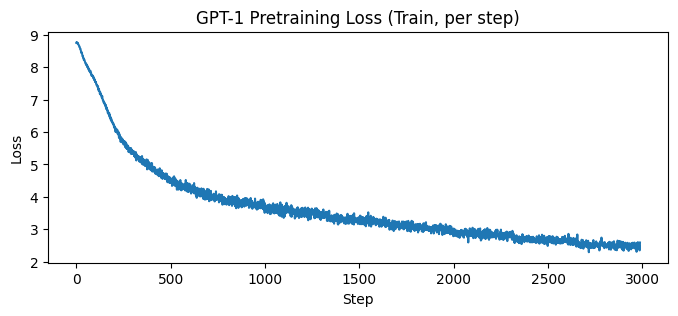

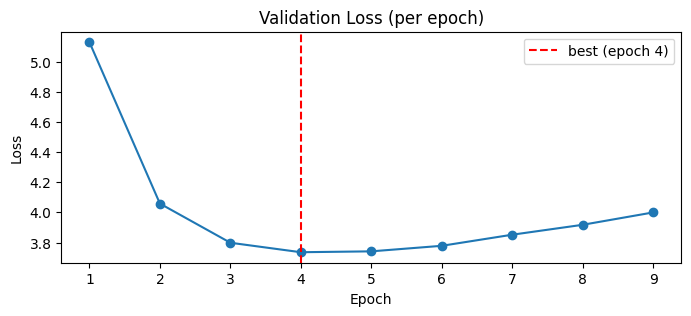

In [24]:
# 학습/검증 손실 곡선 (Val Loss가 오르기 시작하는 지점 = 과적합 시작)
plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("GPT-1 Pretraining Loss (Train, per step)")
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(range(1, len(val_history) + 1), val_history, marker="o")
plt.axvline(best_epoch, color="red", linestyle="--", label=f"best (epoch {best_epoch})")   # [v3 추가]
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss (per epoch)")
plt.legend()
plt.show()

### 문장 생성 — 평가기준 5

Transformer 노드: 질문을 인코더에 넣고 디코더가 `<start>`부터 생성
**GPT [변경]**: 학습 데이터와 같은 형태의 프롬프트 `<start> 질문 <sep>` 를 주고, 그 **뒤를 자기회귀로 이어쓰게** 한다. `<end>`가 나오면 종료.
(과제 기준: 출력 품질과 무관하게 모델이 정상 동작하는지 확인)


In [25]:
def generate_answer(sentence, model, max_gen=MAX_LEN, temperature=1.0, top_k=0):
    """[변경] GPT 방식 생성: '<start> 질문 <sep>' 프롬프트 뒤를 이어쓰기
    [v3 추가] 디코딩 옵션
      - top_k=0            : greedy (항상 확률 1위 토큰 — 결정적, 매번 같은 답)
      - top_k>0, temperature: 상위 k개 중 확률적 샘플링 (다양한 답, 반복 완화)"""
    model.eval()

    tokens = mecab.morphs(preprocess_sentence(sentence))
    prompt_ids = ([vocab["<start>"]]
                  + [vocab.get(tok, vocab["<unk>"]) for tok in tokens]
                  + [vocab["<sep>"]])

    output = torch.tensor([prompt_ids], dtype=torch.long, device=device)

    result_ids = []
    with torch.no_grad():
        for _ in range(max_gen):
            if output.size(1) >= POS_LEN:   # 위치 임베딩 범위 초과 방지
                break

            mask = generate_gpt_mask(output)
            logits, _ = model(output, mask)

            last_logits = logits[0, -1]
            last_logits[vocab["<pad>"]] = float("-inf")   # [v3 추가] <pad>는 생성 금지

            if top_k > 0:
                # [v3 추가] temperature로 분포를 조절한 뒤 상위 k개에서 샘플링
                scaled = last_logits / max(temperature, 1e-6)
                topv, topi = torch.topk(scaled, top_k)
                probs = F.softmax(topv, dim=-1)
                predicted_id = topi[torch.multinomial(probs, 1)].item()
            else:
                predicted_id = last_logits.argmax(dim=-1).item()   # greedy

            if predicted_id == vocab["<end>"]:
                break

            result_ids.append(predicted_id)
            new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
            output = torch.cat([output, new_token], dim=1)

    return " ".join(idx2word.get(i, "<unk>") for i in result_ids)

In [26]:
# [평가기준 5] 입력에 따른 출력 생성 확인 — greedy vs 샘플링 비교
example_questions = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

print("=" * 60)
print("Greedy decoding (결정적 — 매번 같은 답)")
print("=" * 60)
for i, q in enumerate(example_questions, 1):
    print(f"Q{i}: {q}")
    print(f"A{i}: {generate_answer(q, gpt)}")
    print()

print("=" * 60)
print("Top-k 샘플링 (top_k=10, temperature=0.8 — 실행마다 달라짐)")
print("=" * 60)
for i, q in enumerate(example_questions, 1):
    print(f"Q{i}: {q}")
    for trial in range(3):   # 같은 질문 3번 → 다양성 확인
        print(f"  시도{trial+1}: {generate_answer(q, gpt, temperature=0.8, top_k=10)}")
    print()

Greedy decoding (결정적 — 매번 같은 답)
Q1: 지루하다, 놀러가고 싶어.
A1: 저 도 잘 할 수 있 어요 .

Q2: 오늘 일찍 일어났더니 피곤하다.
A2: 마음 이 많이 힘들 겠 어요 .

Q3: 간만에 여자친구랑 데이트 하기로 했어.
A3: 좋 은 사람 이 네요 .

Q4: 집에 있는다는 소리야.
A4: 저 도 잘 해 보 세요 .

Top-k 샘플링 (top_k=10, temperature=0.8 — 실행마다 달라짐)
Q1: 지루하다, 놀러가고 싶어.
  시도1: 저 도 잘 하 고 있 어요 .
  시도2: 저 만 해요 .
  시도3: 저 도 하 고 하 는 게 좋 아 해요 .

Q2: 오늘 일찍 일어났더니 피곤하다.
  시도1: 더 많이 생각 하 겠 네요 .
  시도2: 많이 힘들 지 않 는 사람 이 에요 .
  시도3: 많이 사랑 하 지 않 았 어요 .

Q3: 간만에 여자친구랑 데이트 하기로 했어.
  시도1: 자신 의 선택 할 것 같 아요 .
  시도2: 좋 은 일 이 에요 .
  시도3: 서로 에게 잘 했 던 사람 이 필요 한 것 같 네요 .

Q4: 집에 있는다는 소리야.
  시도1: 잘 할 수 있 어요 .
  시도2: 좋 은 것 예요 .
  시도3: 좋 은 시간 이 에요 .



## 회고

20에폭에서 Val Loss가 에폭 4 이후 상승(과적합 확인) → 정규화·early stopping 적용 후에도 최저점 3.74 불변 → 병목이 데이터임을 규명, 개선하려면 BPE 토크나이저·데이터 확충 필요"
